In [3]:
#SJL 1/2020
#Script to plot the change in surface length for planets for an example tidal evolution
#plots on a 2D map showing the change in shape and surface

###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

import csv 

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
#from matplotlib.mlab import griddata
from scipy.interpolate import griddata

from scipy import interpolate

#plotting packages
import matplotlib as mpl
#mpl.use('PDF')
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec


cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")


#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')

In [4]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

In [5]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#flag as to whether to run in plotting mode or whether to redo calculations
flag_calc=0

#number of contor for contour plot
Ncont=100
Nplot=250
AM_plot=np.linspace(0,3.2, Nplot)

#select crust amounts to plot
Ncrust=[1.,3.0,10]
Mfpoints=np.asarray(Ncrust)*2.77E22/MEarth

print('done')

done


In [33]:
########################################################################################
########################################################################################
########################################################################################
#MAIN



########################################################################################
#read in the database

Hdatabase=HERCULES_random_planet_database_1D()
Hdatabase.make_array(Hdir,Hname)
Hdatabase.initialize_interpolation([0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                    [0,0,Mfpoints.tolist(),0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],0], flag_extrap=1)

#extract the latitudes for each Mu point
Nmu=Hdatabase.parr[0].Nmu
lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi

#     temp_data=Hdatabase.interp_database(L_compare,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
#                                        [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)
    
#     temp=np.asarray(temp_data[16])
    
#     dl_lat_comp=temp[:,0]
#     dl_lon_comp=temp[:,1]
#     dA_comp=temp[:,2]

[0.00463831 0.01391494 0.04638312]
Earth_correct_params_S3.20c
	 Earth_correct_params_S3.20c_AM3.3125
	 Earth_correct_params_S3.20c_AM3.30625
	 Earth_correct_params_S3.20c_AM3.325


In [55]:
###########################################
#Contour plot

#now run through all AM examples and calculate the gravity
print('begin')

checkpoints=np.linspace(1,101,101)

gtot=np.zeros((np.size(AM_plot),Nmu))

for i in np.arange(np.size(AM_plot)):
    if (i*1.0/Nplot*100)>checkpoints[0]:
        print(i*1.0/Nplot*100, '%')
        checkpoints=checkpoints[1:]
        
    temp_data=Hdatabase.interp_database(AM_plot[i]*LEM,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                       [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],0],flag_extrap=1)

    temp=np.asarray(temp_data[18])
    gtot[i,:]=np.asarray(temp[:,0])
    
    
print(np.amax(gtot), np.amin(gtot))
print('end')

begin
1.2 %
2.4 %
3.2 %
4.3999999999999995 %
5.2 %
6.4 %
7.199999999999999 %
8.4 %
9.2 %
10.4 %
11.200000000000001 %
12.4 %
13.200000000000001 %
14.000000000000002 %
15.2 %
16.400000000000002 %
17.2 %
18.4 %
19.2 %
20.4 %
21.2 %
22.400000000000002 %
23.200000000000003 %
24.4 %
25.2 %
26.400000000000002 %
27.200000000000003 %
28.000000000000004 %
29.2 %
30.4 %
31.2 %
32.4 %
33.2 %
34.4 %
35.199999999999996 %
36.4 %
37.2 %
38.4 %
39.2 %
40.400000000000006 %
41.199999999999996 %
42.4 %
43.2 %
44.4 %
45.2 %
46.400000000000006 %
47.199999999999996 %
48.4 %
49.2 %
50.4 %
51.2 %
52.400000000000006 %
53.2 %
54.400000000000006 %
55.2 %
56.00000000000001 %
57.199999999999996 %
58.4 %
59.199999999999996 %
60.4 %
61.199999999999996 %
62.4 %
63.2 %
64.4 %
65.2 %
66.4 %
67.2 %
68.4 %
69.19999999999999 %
70.39999999999999 %
71.2 %
72.39999999999999 %
73.2 %
74.4 %
75.2 %
76.4 %
77.2 %
78.4 %
79.2 %
80.4 %
81.2 %
82.39999999999999 %
83.2 %
84.39999999999999 %
85.2 %
86.4 %
87.2 %
88.4 %
89.2 %
90.4 %


In [56]:
#calculate the interpolation hulls
lat_grid=np.linspace(0, 90, Ncont*(Ncont+1))
AM_grid=np.linspace(AM_plot[0], AM_plot[-1],Ncont*(Ncont+1))

LLL, TTT = np.meshgrid(AM_grid, lat_grid)

temp=np.ones(np.shape(gtot))
AM=temp*AM_plot[:, None]

lat=temp*(90-np.arccos(Hdatabase.parr[0].mu)*180/np.pi)[None,:]

GGG=griddata(((AM.flatten(),lat.flatten())),gtot.flatten(),(LLL,TTT))#, method='linear')
 
print('done')

done


<ipython-input-93-89b95f8d51af>:30: MatplotlibDeprecationWarning: Support for setting the 'text.latex.preamble' or 'pgf.preamble' rcParam to a list of strings is deprecated since 3.3 and will be removed two minor releases later; set it to a single string instead.
  mpl.rcParams['text.latex.preamble'] = [


done


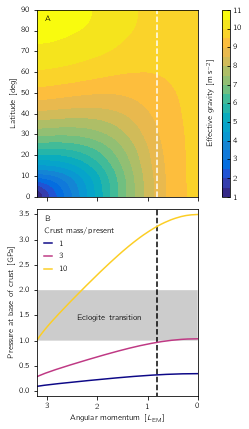

In [93]:
###########################################################################################
###########################################################################################
###########################################################################################
#make a combined plot
#Note: must run previous calculations
#SJL 4/23

###########################################################################################
###########################################################################################
###########################################################################################
#initialise the figure
fig = plt.figure(figsize=(3.5,6))
gs = gridspec.GridSpec(2, 2,
                      width_ratios=[1,0.05],
                      height_ratios=[1,1])
ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[2],sharex=ax[0][0]))

ax_col=[[]]
ax_col[0].append(plt.subplot(gs[1]))

font = {
#         'family':'sans-serif',
#         'sans-serif':['Helvetica'],
# 'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rcParams['text.latex.preamble'] = [
        r'\usepackage{helvet}',    # set the normal font here
       r'\usepackage{sansmath}',  # load up the sansmath so that math -> helvet
       r'\sansmath'               # <- tricky! -- gotta actually tell tex to use!
]  


mpl.rc('text.latex', preamble=r'\usepackage{cmbright}')
mpl.rcParams['text.usetex'] = True
mpl.rc('font', **font)

g_contours=np.linspace(1,11,20+1)

g_labels=np.asarray([1,2,3,4,5,6,7,8,9,10,11])


contour1 = ax[0][0].contourf(LLL, TTT, GGG, levels=g_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(g_contours)-1)))


#draw lines at Roche limit AM
L_Roche=(LEM)-(MMoon)*np.sqrt(const.G*aRoche*MEarth)
temp=ax[0][0].plot([L_Roche/LEM,L_Roche/LEM], [0,90],'w--',linewidth=1.5)

ax[0][0].set_xlim([3.2, 0.0])


#label axis
cbar1=plt.colorbar(contour1, cax=ax_col[0][0], orientation='vertical',ticks=g_labels)

cbar1.set_label(r'Effective surface gravity [m s$^{-2}$]', labelpad=-36)

for i in np.arange(1):
    ax_col[0][i].tick_params(direction="in")
    
######
#Now plot the lower panel
ax[0][1].fill_between(AM_grid, np.ones(np.size(AM_grid)), 2.0*np.ones(np.size(AM_grid)), alpha=0.2, color='k',edgecolor=None)

ax[0][1].plot([L_Roche/LEM,L_Roche/LEM], [-1,4],'k--',linewidth=1.5)

col=cm.plasma(np.linspace(0,0.9,np.size(Mfpoints)))
for i in np.arange(np.size(Mfpoints)):
    ax[0][1].plot(AM_grid,pMfrac[:,i]/1E9,label=int(Ncrust[i]),color=col[i],linewidth=1.5)
    
# ax[0][0].set_yscale('log')
ax[0][1].set_xlim([3.2, 0.0])
leg=ax[0][1].legend(title="Crust mass/present", frameon=False, loc='upper left',bbox_to_anchor=(0.0,0.95),handlelength=1)
leg._legend_box.align = "left"

ax[0][1].text(0.45, (1.5/3.6), 'Eclogite transition', horizontalalignment='center',verticalalignment='center', fontsize=8,transform=ax[0][1].transAxes, color='k')
        
ax[0][0].set_ylabel("Latitude [deg]")
plt.setp( ax[0][0].get_xticklabels(), visible=False)
ax[0][1].set_ylabel("Pressure at base of crust [GPa]")
ax[0][1].set_xlabel(r"Angular momentum [$L_{\rm EM}$]")

ax[0][0].text(0.05, 0.965, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.05, 0.965, 'b', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][1].transAxes, color='k')

ax[0][1].set_ylim([-0.1,3.6])

fig.tight_layout()
plt.savefig('Example_gravity_plot_contours_wt_crust_pressure.pdf')

print('done')